# 01 · Benchmark Analysis — Model × Strategy

Comparison of **3 models** × **3 prompting strategies** on MMLU and HumanEval datasets.

| Dimension | Values |
|---|---|
| **Models** | `qwen3-coder:480b-cloud`, `gemma3:27b-cloud`, `gpt-oss:20b-cloud` |
| **Strategies** | `zero_shot`, `few_shot`, `chain_of_thought` |
| **Metrics** | Accuracy (judge_correct), ROUGE-L, BLEU, LLM-as-judge score |

**Input:** `results/benchmark/*.json` — generated by `uv run run-benchmark --all-strategies`  
**Output:** heatmaps, grouped bar charts, model ranking

> **Prerequisite:**
> ```bash
> uv run build-datasets --skip-rag-qa
> uv run run-benchmark --all-strategies
> ```

In [14]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.15)
plt.rcParams['figure.dpi'] = 130

NOTEBOOK_DIR = Path().resolve()
ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
RESULTS_DIR  = ROOT / 'results' / 'benchmark'

# Friendly model labels (strip '-cloud' suffix for readability)
MODEL_LABELS = {
    'qwen3-coder:480b-cloud': 'Qwen3-Coder 480B',
    'gemma3:27b-cloud':       'Gemma3 27B',
    'gpt-oss:20b-cloud':      'GPT-OSS 20B',
}
STRATEGY_ORDER = ['zero_shot', 'few_shot', 'chain_of_thought']
STRATEGY_LABELS = {'zero_shot': 'Zero-Shot', 'few_shot': 'Few-Shot', 'chain_of_thought': 'CoT'}

print('Results dir :', RESULTS_DIR)
print('JSON files  :', sorted(p.name for p in RESULTS_DIR.glob('*.json')))


Results dir : C:\Users\otnie\OneDrive\Documentos\GitHub\LLM-Eval-Suite\results\benchmark
JSON files  : ['chain_of_thought_gemma3-27b-cloud.json', 'chain_of_thought_gpt-oss-20b-cloud.json', 'chain_of_thought_qwen3-coder-480b-cloud.json', 'few_shot_gemma3-27b-cloud.json', 'few_shot_gpt-oss-20b-cloud.json', 'few_shot_qwen3-coder-480b-cloud.json', 'zero_shot_gemma3-27b-cloud.json', 'zero_shot_gpt-oss-20b-cloud.json', 'zero_shot_qwen3-coder-480b-cloud.json']


## 1 · Load results

In [15]:
json_files = sorted(RESULTS_DIR.glob('*.json'))
if not json_files:
    raise FileNotFoundError(f'No result files in: {RESULTS_DIR}\nRun: uv run run-benchmark --all-strategies')

records = []
for path in json_files:
    with open(path, encoding='utf-8') as f:
        data = json.load(f)
    rows = data if isinstance(data, list) else data.get('results', [])

    if path.stem.startswith('chain_of_thought_'):
        file_strategy = 'chain_of_thought'
        file_model    = path.stem[len('chain_of_thought_'):]
    elif path.stem.startswith('few_shot_'):
        file_strategy = 'few_shot'
        file_model    = path.stem[len('few_shot_'):]
    elif path.stem.startswith('zero_shot_'):
        file_strategy = 'zero_shot'
        file_model    = path.stem[len('zero_shot_'):]
    else:
        parts = path.stem.split('_', 1)
        file_strategy, file_model = parts[0], parts[1] if len(parts) > 1 else 'unknown'

    # Normalise model slug to match MODEL_LABELS keys
    file_model_norm = file_model.replace('-', ':')

    for row in rows:
        row.setdefault('strategy', file_strategy)
        row.setdefault('model',    file_model_norm)
        records.append(row)

df = pd.DataFrame(records)
if 'judge_correct' in df.columns:
    df['judge_correct'] = df['judge_correct'].astype(bool)

# Apply friendly labels
df['model_label']    = df['model'].map(MODEL_LABELS).fillna(df['model'])
df['strategy_label'] = df['strategy'].map(STRATEGY_LABELS).fillna(df['strategy'])

print(f'{len(df)} rows loaded')
print('Models     :', df['model_label'].unique().tolist())
print('Strategies :', df['strategy'].unique().tolist())
df.groupby(['model_label', 'strategy'])['judge_correct'].count().unstack()


450 rows loaded
Models     : ['Gemma3 27B', 'GPT-OSS 20B', 'Qwen3-Coder 480B']
Strategies : ['chain_of_thought', 'few_shot', 'zero_shot']


strategy,chain_of_thought,few_shot,zero_shot
model_label,,,
GPT-OSS 20B,50,50,50
Gemma3 27B,50,50,50
Qwen3-Coder 480B,50,50,50


## 2 · Summary per model × strategy

In [16]:
agg_cols = {k: 'mean' for k in ['judge_correct', 'rougeL', 'bleu', 'judge_score', 'latency_ms'] if k in df.columns}
summary = (
    df.groupby(['model_label', 'strategy'])
    .agg(agg_cols)
    .rename(columns={'judge_correct': 'Accuracy', 'rougeL': 'ROUGE-L',
                     'bleu': 'BLEU', 'judge_score': 'Judge Score', 'latency_ms': 'Latency (ms)'})
    .round(4)
    .reset_index()
)
summary


,model_label,strategy,Accuracy,ROUGE-L,BLEU,Judge Score,Latency (ms)
0,GPT-OSS 20B,chain_of_thought,0.08,0.0091,0.0000,1.32,4441.12
1,GPT-OSS 20B,few_shot,0.04,0.1602,0.0285,1.16,2682.80
2,GPT-OSS 20B,zero_shot,0.00,0.0409,0.0071,1.00,3554.34
3,Gemma3 27B,chain_of_thought,0.88,0.0086,0.0007,4.82,23939.44
4,Gemma3 27B,few_shot,0.64,0.6600,0.1173,3.68,925.94
5,Gemma3 27B,zero_shot,0.68,0.6800,0.1209,3.78,964.48
6,Qwen3-Coder 480B,chain_of_thought,0.90,0.0088,0.0003,4.74,11817.80
7,Qwen3-Coder 480B,few_shot,0.88,0.8800,0.1565,4.52,1151.88
8,Qwen3-Coder 480B,zero_shot,0.90,0.6989,0.0996,4.62,4143.72


## 3 · Accuracy heatmap — model × strategy

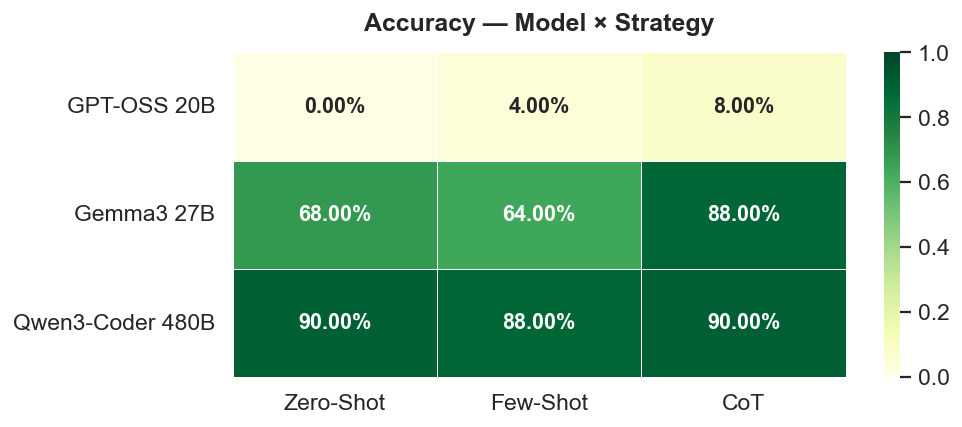

In [17]:
if 'Accuracy' not in summary.columns:
    print('Accuracy column not found — skipping.')
else:
    pivot = summary.pivot(index='model_label', columns='strategy', values='Accuracy')
    # Reorder columns if present
    col_order = [c for c in STRATEGY_ORDER if c in pivot.columns]
    pivot = pivot[col_order]
    pivot.columns = [STRATEGY_LABELS.get(c, c) for c in pivot.columns]

    fig, ax = plt.subplots(figsize=(8, 3.5))
    sns.heatmap(
        pivot, annot=True, fmt='.2%', cmap='YlGn',
        vmin=0, vmax=1, linewidths=0.5, ax=ax,
        annot_kws={'size': 12, 'weight': 'bold'}
    )
    ax.set_title('Accuracy — Model × Strategy', fontweight='bold', pad=12)
    ax.set_xlabel('')
    ax.set_ylabel('')
    plt.tight_layout()
    plt.savefig('benchmark_accuracy_heatmap.png', bbox_inches='tight')
    plt.show()


## 4 · Accuracy — grouped bar per strategy

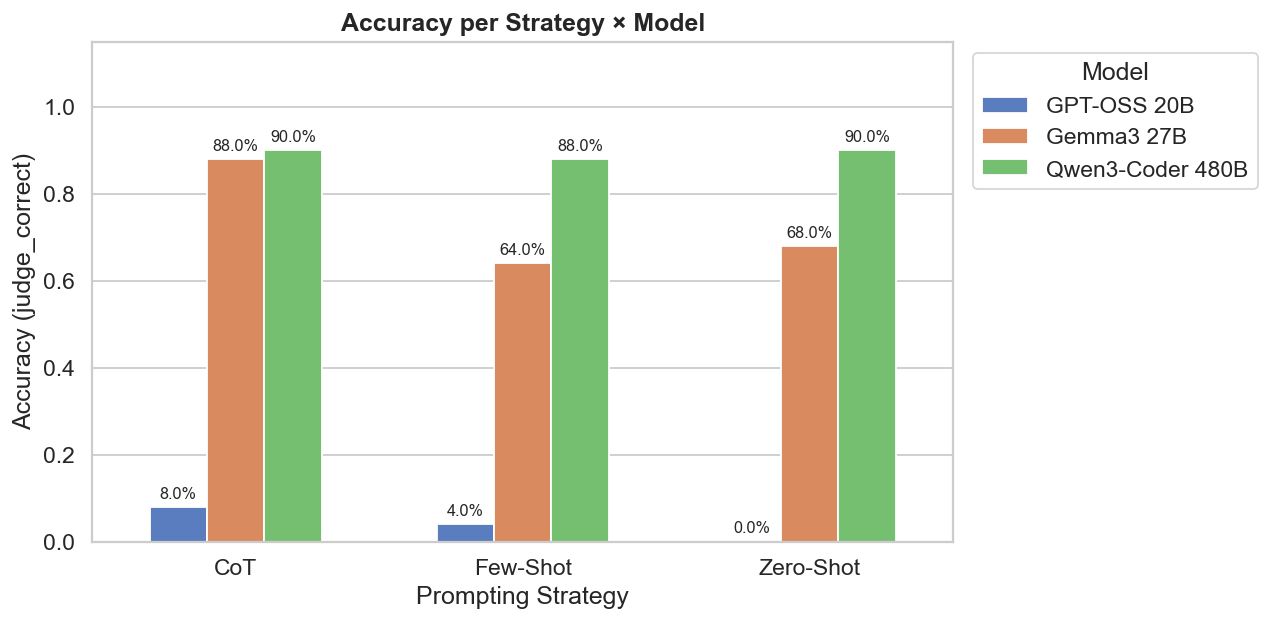

In [18]:
if 'Accuracy' not in summary.columns:
    print('Accuracy column not found — skipping.')
else:
    summary['strategy_label'] = summary['strategy'].map(STRATEGY_LABELS).fillna(summary['strategy'])
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(
        data=summary, x='strategy_label', y='Accuracy',
        hue='model_label', ax=ax, width=0.6
    )
    for container in ax.containers:
        ax.bar_label(container, fmt='{:.1%}', padding=3, fontsize=9)
    ax.set_ylim(0, 1.15)
    ax.set_title('Accuracy per Strategy × Model', fontweight='bold')
    ax.set_xlabel('Prompting Strategy')
    ax.set_ylabel('Accuracy (judge_correct)')
    ax.legend(title='Model', bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig('benchmark_accuracy_grouped.png', bbox_inches='tight')
    plt.show()


## 5 · Best strategy per model

In [19]:
if 'Accuracy' not in summary.columns:
    print('Accuracy column not found — skipping.')
else:
    best = (
        summary.loc[summary.groupby('model_label')['Accuracy'].idxmax()]
        [['model_label', 'strategy', 'Accuracy']]
        .rename(columns={'model_label': 'Model', 'strategy': 'Best Strategy', 'Accuracy': 'Best Accuracy'})
        .sort_values('Best Accuracy', ascending=False)
        .reset_index(drop=True)
    )
    print(best.to_string(index=False))
    best


           Model    Best Strategy  Best Accuracy
Qwen3-Coder 480B chain_of_thought           0.90
      Gemma3 27B chain_of_thought           0.88
     GPT-OSS 20B chain_of_thought           0.08


## 6 · LLM-as-judge score — model × strategy

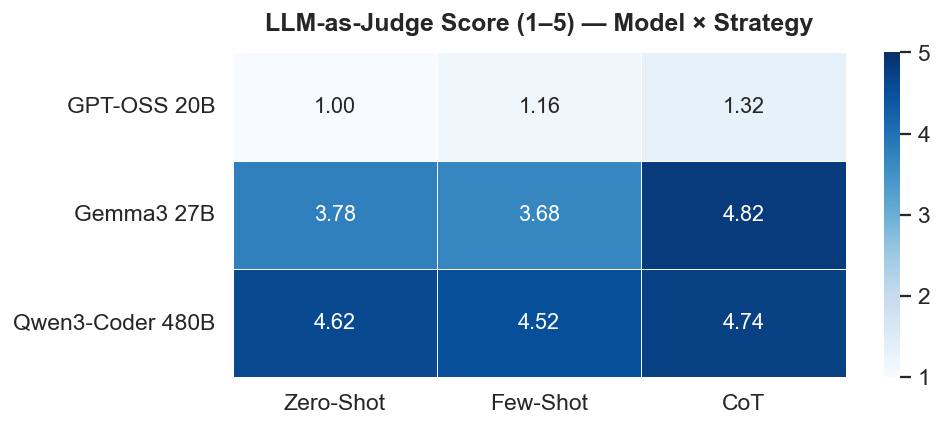

In [20]:
if 'Judge Score' not in summary.columns:
    print('Judge Score column not found — skipping.')
else:
    pivot_j = summary.pivot(index='model_label', columns='strategy', values='Judge Score')
    col_order = [c for c in STRATEGY_ORDER if c in pivot_j.columns]
    pivot_j = pivot_j[col_order]
    pivot_j.columns = [STRATEGY_LABELS.get(c, c) for c in pivot_j.columns]

    fig, ax = plt.subplots(figsize=(8, 3.5))
    sns.heatmap(
        pivot_j, annot=True, fmt='.2f', cmap='Blues',
        vmin=1, vmax=5, linewidths=0.5, ax=ax,
        annot_kws={'size': 12}
    )
    ax.set_title('LLM-as-Judge Score (1–5) — Model × Strategy', fontweight='bold', pad=12)
    ax.set_xlabel('')
    ax.set_ylabel('')
    plt.tight_layout()
    plt.savefig('benchmark_judge_heatmap.png', bbox_inches='tight')
    plt.show()


## 7 · ROUGE-L heatmap — model × strategy

> ⚠️ For MCQ benchmarks, low ROUGE-L on CoT is expected (long reasoning vs. single-letter reference). Use Accuracy as the primary metric.

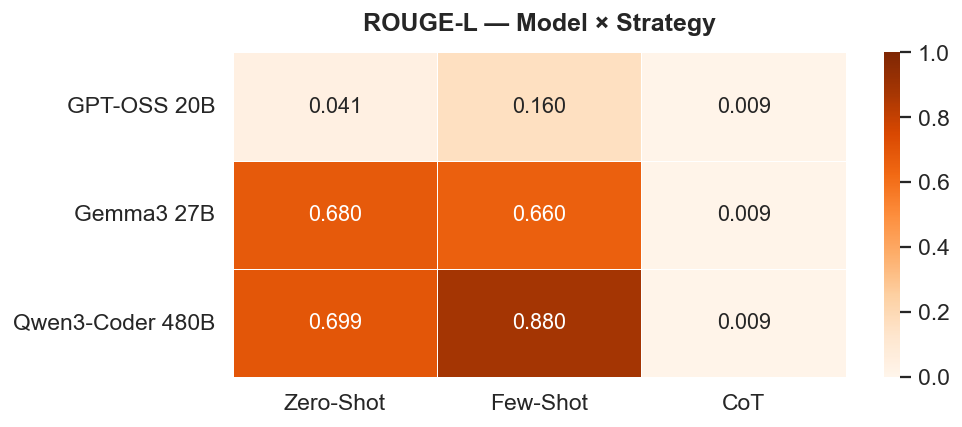

In [21]:
if 'ROUGE-L' not in summary.columns:
    print('ROUGE-L column not found — skipping.')
else:
    pivot_r = summary.pivot(index='model_label', columns='strategy', values='ROUGE-L')
    col_order = [c for c in STRATEGY_ORDER if c in pivot_r.columns]
    pivot_r = pivot_r[col_order]
    pivot_r.columns = [STRATEGY_LABELS.get(c, c) for c in pivot_r.columns]

    fig, ax = plt.subplots(figsize=(8, 3.5))
    sns.heatmap(
        pivot_r, annot=True, fmt='.3f', cmap='Oranges',
        vmin=0, vmax=1, linewidths=0.5, ax=ax,
        annot_kws={'size': 12}
    )
    ax.set_title('ROUGE-L — Model × Strategy', fontweight='bold', pad=12)
    ax.set_xlabel('')
    ax.set_ylabel('')
    plt.tight_layout()
    plt.savefig('benchmark_rougeL_heatmap.png', bbox_inches='tight')
    plt.show()


## 8 · Latency — model × strategy

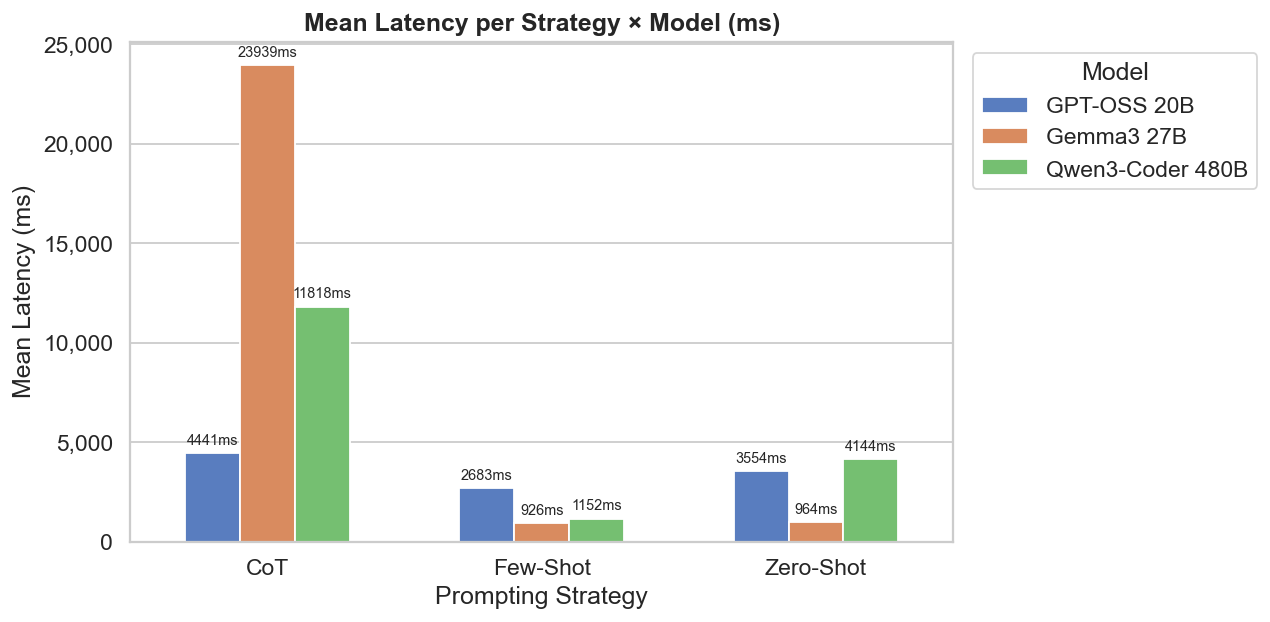

In [22]:
if 'Latency (ms)' not in summary.columns:
    print('Latency column not found — skipping.')
else:
    summary['strategy_label'] = summary['strategy'].map(STRATEGY_LABELS).fillna(summary['strategy'])
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(
        data=summary, x='strategy_label', y='Latency (ms)',
        hue='model_label', ax=ax, width=0.6
    )
    for container in ax.containers:
        ax.bar_label(container, fmt='{:.0f}ms', padding=3, fontsize=8)
    ax.set_title('Mean Latency per Strategy × Model (ms)', fontweight='bold')
    ax.set_xlabel('Prompting Strategy')
    ax.set_ylabel('Mean Latency (ms)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.legend(title='Model', bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig('benchmark_latency.png', bbox_inches='tight')
    plt.show()


## 9 · Overall model ranking (mean across all strategies)

In [23]:
quality_cols = [c for c in ['Accuracy', 'ROUGE-L', 'BLEU', 'Judge Score'] if c in summary.columns]
latency_cols = [c for c in ['Latency (ms)'] if c in summary.columns]

model_rank = (
    summary.groupby('model_label')[quality_cols + latency_cols]
    .mean()
    .sort_values('Accuracy', ascending=False)
    .round(4)
)

styler = model_rank.style.format(precision=4).set_caption('Overall Model Ranking (avg across all strategies)')
if quality_cols:
    styler = styler.background_gradient(cmap='Greens', subset=quality_cols)
if latency_cols:
    styler = styler.background_gradient(cmap='Reds_r', subset=latency_cols)
styler


,Accuracy,ROUGE-L,BLEU,Judge Score,Latency (ms)
model_label,,,,,
Qwen3-Coder 480B,0.8933,0.5292,0.0855,4.6267,5704.4667
Gemma3 27B,0.7333,0.4495,0.0796,4.0933,8609.9533
GPT-OSS 20B,0.0400,0.0701,0.0119,1.1600,3559.4200


## 10 · Strategy ranking (mean across all models)

In [24]:
strategy_rank = (
    summary.groupby('strategy')[quality_cols + latency_cols]
    .mean()
    .sort_values('Accuracy', ascending=False)
    .round(4)
)
strategy_rank.index = strategy_rank.index.map(STRATEGY_LABELS)

styler2 = strategy_rank.style.format(precision=4).set_caption('Strategy Ranking (avg across all models)')
if quality_cols:
    styler2 = styler2.background_gradient(cmap='Greens', subset=quality_cols)
if latency_cols:
    styler2 = styler2.background_gradient(cmap='Reds_r', subset=latency_cols)
styler2


,Accuracy,ROUGE-L,BLEU,Judge Score,Latency (ms)
strategy,,,,,
CoT,0.6200,0.0088,0.0003,3.6267,13399.4533
Zero-Shot,0.5267,0.4733,0.0759,3.1333,2887.5133
Few-Shot,0.5200,0.5667,0.1008,3.1200,1586.8733


## 11 · Conclusions

### By model

- **Best overall accuracy:** Qwen3-Coder 480B with a mean of **89.3%** across all
  strategies (Zero-Shot 90% + Few-Shot 88% + CoT 90% ÷ 3). Gemma3 27B ranks
  second with 73.3% (68% + 64% + 88% ÷ 3). GPT-OSS 20B discarded (4% avg).

- **Best quality/latency trade-off:** Qwen3-Coder 480B + Zero-Shot — 90%
  accuracy with only ~4.1s mean latency, without the extra reasoning cost of
  CoT (~11.8s). Delivers the same accuracy ceiling at 3× lower latency.

- **Largest CoT improvement:** Gemma3 27B — jumped from 64–68% (Zero/Few-Shot)
  to 88% with CoT, a gain of +20–24pp. The smaller model benefits far more from
  explicit reasoning than Qwen3, which holds 90% regardless of strategy. This
  suggests that CoT compensates for Gemma3's lower parametric capacity by
  externalizing the reasoning structure.

---

### By strategy

- **CoT vs Zero-Shot delta:** +20pp for Gemma3 (88% vs 68%) and 0pp for
  Qwen3 (90% vs 90%). **The extra CoT latency is only worth it for Gemma3** —
  Qwen3 does not need it (and costs 2.9× more: 11.8s vs 4.1s). For GPT-OSS,
  CoT helps marginally (8% vs 0%), but the baseline remains unusable.

- **Few-Shot advantage:** **Negative or neutral** across all tested models.
  Gemma3 drops from 68% (Zero-Shot) to 64% with Few-Shot — the examples
  confuse more than they help. Qwen3 drops from 90% to 88% — marginal impact.
  Few-Shot adds no value for this model × MMLU dataset combination; it adds
  context tokens without any accuracy gain.

---

### Insights

- **ROUGE-L is not a reliable quality proxy for MCQ** — CoT deflates the score
  to ~0.009 across all models (long reasoning chain vs. a single-letter answer),
  while Zero/Few-Shot reach 0.699–0.880 simply by producing shorter outputs.
  ROUGE-L here measures brevity, not quality.

- **Judge Score does not saturate for all models** — GPT-OSS 20B scores 1.00–1.32,
  confirming that the judge detects the absence of a valid response. The key
  divergence is that Gemma3 receives 4.82 on CoT (above Qwen3's 4.74) despite
  lower accuracy — the judge evaluates fluency and completeness of reasoning,
  not the final answer letter.

- **Production recommendation:** In this scenario, `Qwen3-Coder 480B + Zero-Shot`
  is the most suitable choice for production. Highest accuracy (90%), lowest
  latency (~4.1s), no dependency on prompt engineering strategy. Use CoT only
  in offline pipelines or when the latency SLO allows >10s per query. Discard
  GPT-OSS 20B for reasoning tasks; re-evaluate only for simple generation tasks
  (summarization, extraction).